# ZZU Main Experiment Runner

This notebook is the main file for running the ZZU transformation experiments on the toy datasets.

It assumes these two Python scripts are in the same folder as this notebook:

- `toy_data.py`
- `transformation_algorithms.py`

The notebook:

1. imports the dataset generators from `toy_data.py`,
2. imports the transformation models from `transformation_algorithms.py`,
3. generates the default toy-data suite,
4. runs the transformation algorithms on each dataset,
5. summarizes predictive performance,
6. plots the best fits for one-dimensional datasets,
7. runs a repeated-split robustness check, and
8. saves result tables to CSV.

This version uses normal Python imports instead of `%run`, so it is better suited to Google Colab and a modular project layout.


## 1. Setup

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 80)
PROJECT_DIR = Path.cwd()

required_files = ["toy_data.py", "transformation_algorithms.py"]
missing = [name for name in required_files if not (PROJECT_DIR / name).exists()]

if missing:
    raise FileNotFoundError(
        "Missing required script(s): "
        + ", ".join(missing)
        + f"\nCurrent PROJECT_DIR is: {PROJECT_DIR}"
        + "\nUpload the scripts to this folder or update PROJECT_DIR."
    )

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print(f"Using project directory: {PROJECT_DIR}")
print("Found required scripts:", ", ".join(required_files))


Using project directory: /Users/ardauzunoglu/zzu-transformations
Found required scripts: toy_data.py, transformation_algorithms.py


In [2]:
RELOAD_MODULES = False

def load_project_module(module_name: str):
    """Import or optionally reload a local project module."""
    if module_name in sys.modules and RELOAD_MODULES:
        return importlib.reload(sys.modules[module_name])
    if module_name in sys.modules:
        return sys.modules[module_name]
    return importlib.import_module(module_name)

# Suppress import-time plots from scripts converted from notebooks.
_original_show = plt.show
try:
    plt.show = lambda *args, **kwargs: None
    td = load_project_module("toy_data")
    ta = load_project_module("transformation_algorithms")
finally:
    plt.show = _original_show
    plt.close("all")

print("Imported modules:")
print("  td =", td.__name__)
print("  ta =", ta.__name__)


Imported modules:
  td = toy_data
  ta = transformation_algorithms


## 3. Generate the toy dataset suite

The default suite contains:

- exponential growth with multiplicative lognormal noise,
- exponential growth with additive Gaussian noise,
- Michaelis--Menten saturation,
- logistic growth,
- multivariable nonlinear data.

In [3]:
suite = td.generate_default_suite()

DATASET_NAMES = [
    "exponential_multiplicative",
    "exponential_additive",
    "michaelis_menten",
    "logistic_growth",
    "multivariable_nonlinear",
]

suite = {name: suite[name] for name in DATASET_NAMES}

summary = td.summarize_suite(suite)
summary


,n,p,y_mean,y_std,y_min,y_max,noise_type,seed
name,,,,,,,,
exponential_multiplicative,120,1,18.5223,18.4463,1.2385e+00,85.2818,multiplicative_lognormal,101
exponential_additive,120,1,18.5526,17.5177,1.0000e-06,68.3474,additive_gaussian,102
michaelis_menten,120,1,7.6159,1.8758,7.9472e-01,9.5393,additive_gaussian,103
logistic_growth,140,1,50.4224,40.9113,-2.0268e+00,105.5840,additive_gaussian,104
multivariable_nonlinear,500,3,47.7625,28.5636,-1.0092e+00,115.7288,additive_gaussian,105


## 4. Define transformation model candidates

Each model is ordinary least squares on a transformed response scale.

The fitted models include:

- identity OLS,
- log-linear OLS,
- reciprocal OLS,
- square-root power-scale OLS,
- Box--Cox OLS with automatically selected $\lambda$,
- Yeo--Johnson OLS with automatically selected $\lambda$.

For nonlinear inverse transformations, both naive inverse prediction and Duan-style smearing correction are included where useful.


In [4]:
LAMBDA_GRID = np.linspace(-2.0, 2.0, 81)

def make_model_specs() -> dict[str, "ta.TransformedOLS"]:
    """Create fresh model instances for one evaluation run."""
    return {
        "identity_ols": ta.TransformedOLS(transform="identity", use_smearing=False),
        "log_naive": ta.TransformedOLS(transform="log", use_smearing=False),
        "log_smearing": ta.TransformedOLS(transform="log", use_smearing=True),
        "reciprocal_naive": ta.TransformedOLS(transform="reciprocal", use_smearing=False),
        "reciprocal_smearing": ta.TransformedOLS(transform="reciprocal", use_smearing=True),
        "sqrt_power_naive": ta.TransformedOLS(transform="power", param=0.5, use_smearing=False),
        "sqrt_power_smearing": ta.TransformedOLS(transform="power", param=0.5, use_smearing=True),
        "boxcox_naive": ta.TransformedOLS(transform="boxcox", use_smearing=False, lambda_grid=LAMBDA_GRID),
        "boxcox_smearing": ta.TransformedOLS(transform="boxcox", use_smearing=True, lambda_grid=LAMBDA_GRID),
        "yeojohnson_naive": ta.TransformedOLS(transform="yeojohnson", use_smearing=False, lambda_grid=LAMBDA_GRID),
        "yeojohnson_smearing": ta.TransformedOLS(transform="yeojohnson", use_smearing=True, lambda_grid=LAMBDA_GRID),
    }

list(make_model_specs().keys())


['identity_ols',
 'log_naive',
 'log_smearing',
 'reciprocal_naive',
 'reciprocal_smearing',
 'sqrt_power_naive',
 'sqrt_power_smearing',
 'boxcox_naive',
 'boxcox_smearing',
 'yeojohnson_naive',
 'yeojohnson_smearing']

## 5. Evaluation helpers

Metrics are computed on the original response scale.

For synthetic data, the notebook reports two target comparisons:

- `*_obs`: prediction error relative to the noisy observed response `y`;
- `*_signal`: prediction error relative to the noiseless true signal `y_true`.

In real data, you would usually only have the observed-response metrics.


In [5]:
def bundle_arrays(bundle):
    """Return X, observed y, and noiseless y_true arrays from a DatasetBundle."""
    X = bundle.X.to_numpy(dtype=float)
    y = bundle.y.to_numpy(dtype=float)
    y_true = bundle.y_true.to_numpy(dtype=float)
    return X, y, y_true


def evaluate_bundle(
    bundle,
    test_size: float = 0.25,
    split_seed: int = 2026,
) -> pd.DataFrame:
    """Fit all transformation models on one dataset bundle and return a metrics table."""
    train_bundle, test_bundle = td.train_test_split_bundle(
        bundle, test_size=test_size, seed=split_seed
    )

    X_train, y_train, _ = bundle_arrays(train_bundle)
    X_test, y_test, y_signal_test = bundle_arrays(test_bundle)

    rows = []
    for model_name, model in make_model_specs().items():
        try:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            obs_metrics = ta.regression_metrics(y_test, y_pred)
            signal_metrics = ta.regression_metrics(y_signal_test, y_pred)
            diagnostics = ta.residual_diagnostics(y_test, y_pred)

            row = {
                "dataset": bundle.name,
                "model": model_name,
                "transform": model.transform,
                "selected_param_or_lambda": model.selected_param_,
                "use_smearing": model.use_smearing,
                "n_train": len(y_train),
                "n_test": len(y_test),
                "split_seed": split_seed,
                "error": "",
                "n_valid_obs": obs_metrics["n_valid"],
                "rmse_obs": obs_metrics["rmse"],
                "mae_obs": obs_metrics["mae"],
                "mse_obs": obs_metrics["mse"],
                "r2_obs": obs_metrics["r2"],
                "n_valid_signal": signal_metrics["n_valid"],
                "rmse_signal": signal_metrics["rmse"],
                "mae_signal": signal_metrics["mae"],
                "mse_signal": signal_metrics["mse"],
                "r2_signal": signal_metrics["r2"],
                **diagnostics,
            }
        except Exception as exc:
            row = {
                "dataset": bundle.name,
                "model": model_name,
                "transform": model.transform,
                "selected_param_or_lambda": np.nan,
                "use_smearing": model.use_smearing,
                "n_train": len(y_train),
                "n_test": len(y_test),
                "split_seed": split_seed,
                "error": str(exc),
                "n_valid_obs": 0,
                "rmse_obs": np.nan,
                "mae_obs": np.nan,
                "mse_obs": np.nan,
                "r2_obs": np.nan,
                "n_valid_signal": 0,
                "rmse_signal": np.nan,
                "mae_signal": np.nan,
                "mse_signal": np.nan,
                "r2_signal": np.nan,
                "residual_mean": np.nan,
                "residual_std": np.nan,
                "residual_skew": np.nan,
                "residual_excess_kurtosis": np.nan,
                "corr_abs_resid_fitted": np.nan,
            }
        rows.append(row)

    out = pd.DataFrame(rows)
    out = out.sort_values(["rmse_obs", "model"], na_position="last").reset_index(drop=True)
    return out


def evaluate_suite(
    suite: dict,
    test_size: float = 0.25,
    split_seed: int = 2026,
) -> pd.DataFrame:
    """Evaluate all datasets in the suite."""
    tables = [
        evaluate_bundle(bundle, test_size=test_size, split_seed=split_seed)
        for bundle in suite.values()
    ]
    return pd.concat(tables, ignore_index=True)


def winners_by_dataset(results: pd.DataFrame, metric: str = "rmse_obs") -> pd.DataFrame:
    """Return the best non-error model per dataset according to a metric."""
    valid = results[results["error"].eq("") & results[metric].notna()].copy()
    valid = valid.sort_values(["dataset", metric, "model"])
    return valid.groupby("dataset", as_index=False).first()


## 6. Run the main transformation comparison


In [6]:
results = evaluate_suite(suite, test_size=0.25, split_seed=2026)

important_cols = [
    "dataset",
    "model",
    "transform",
    "selected_param_or_lambda",
    "use_smearing",
    "rmse_obs",
    "mae_obs",
    "r2_obs",
    "rmse_signal",
    "r2_signal",
    "corr_abs_resid_fitted",
    "error",
]

results[important_cols].head(30)


,dataset,model,transform,selected_param_or_lambda,use_smearing,rmse_obs,mae_obs,r2_obs,rmse_signal,r2_signal,corr_abs_resid_fitted,error
0,exponential_multiplicative,yeojohnson_smearing,yeojohnson,-0.10,True,9.1061,4.9390,0.8273,1.0270,0.9968,0.6642,
1,exponential_multiplicative,boxcox_smearing,boxcox,0.00,True,9.1851,4.9602,0.8243,1.1084,0.9962,0.6568,
2,exponential_multiplicative,log_smearing,log,NaN,True,9.1851,4.9602,0.8243,1.1084,0.9962,0.6568,
3,exponential_multiplicative,yeojohnson_naive,yeojohnson,-0.10,False,9.5356,4.9219,0.8106,2.0077,0.9876,0.6288,
4,exponential_multiplicative,boxcox_naive,boxcox,0.00,False,9.5562,4.9264,0.8098,1.9674,0.9881,0.6257,
5,exponential_multiplicative,log_naive,log,NaN,False,9.5562,4.9264,0.8098,1.9674,0.9881,0.6257,
6,exponential_multiplicative,sqrt_power_smearing,power,0.50,True,11.4899,5.9234,0.7251,5.0646,0.9210,0.5678,
7,exponential_multiplicative,sqrt_power_naive,power,0.50,False,11.5848,5.9045,0.7205,5.1750,0.9175,0.5736,
8,exponential_multiplicative,identity_ols,identity,NaN,False,12.4694,7.6082,0.6762,6.6808,0.8625,0.4873,
9,exponential_multiplicative,reciprocal_smearing,reciprocal,NaN,True,62.5830,29.7019,-7.1565,62.3162,-10.9590,0.7112,


In [7]:
winners = winners_by_dataset(results, metric="rmse_obs")

winner_cols = [
    "dataset",
    "model",
    "transform",
    "selected_param_or_lambda",
    "use_smearing",
    "rmse_obs",
    "mae_obs",
    "r2_obs",
    "rmse_signal",
    "r2_signal",
]

winners[winner_cols]


,dataset,model,transform,selected_param_or_lambda,use_smearing,rmse_obs,mae_obs,r2_obs,rmse_signal,r2_signal
0,exponential_additive,boxcox_smearing,boxcox,0.40,True,7.9975,6.2408,0.8352,3.9189,0.9527
1,exponential_multiplicative,yeojohnson_smearing,yeojohnson,-0.10,True,9.1061,4.9390,0.8273,1.0270,0.9968
2,logistic_growth,identity_ols,identity,0.65,False,10.6192,9.2648,0.9281,9.7302,0.9403
3,michaelis_menten,boxcox_naive,boxcox,2.00,False,0.5945,0.4971,0.8220,0.4751,0.8679
4,multivariable_nonlinear,sqrt_power_naive,power,0.50,False,5.1131,4.1026,0.9709,1.9617,0.9953


## 7. RMSE comparison plot


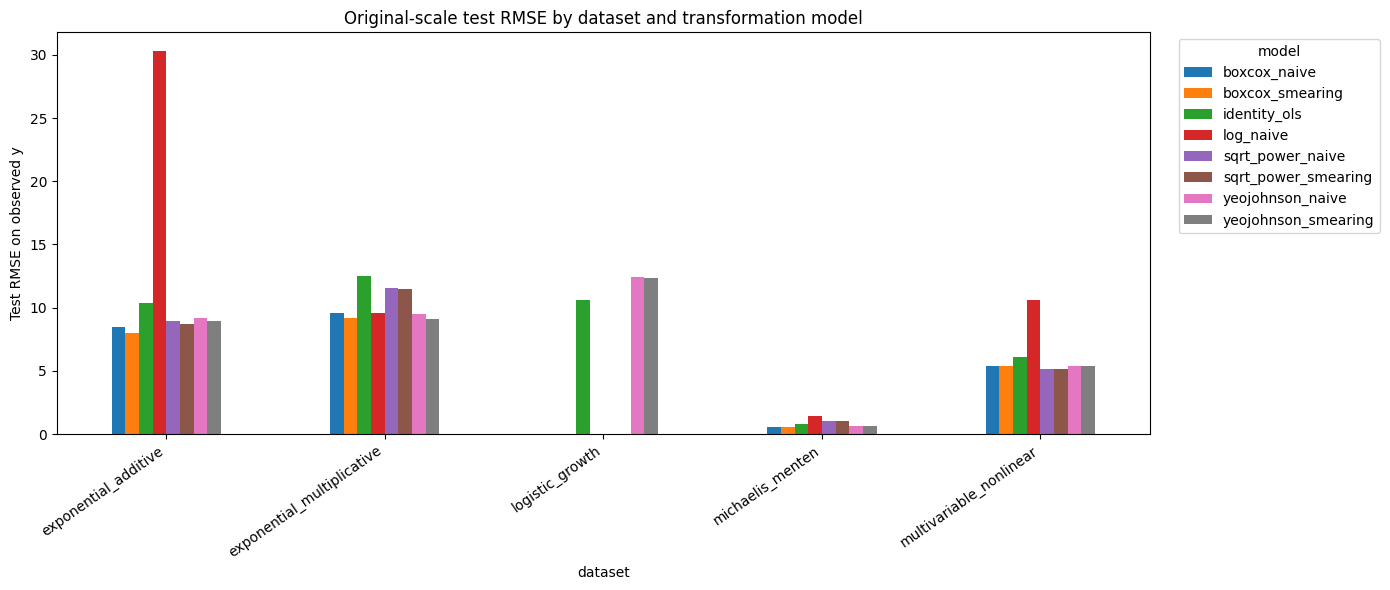

In [8]:
def plot_rmse_comparison(results: pd.DataFrame, max_models: int | None = None):
    """Plot original-scale RMSE by dataset and model."""
    valid = results[results["error"].eq("")].copy()

    if max_models is not None:
        # Keep the globally best models by mean RMSE to reduce clutter.
        keep = (
            valid.groupby("model")["rmse_obs"]
            .mean()
            .sort_values()
            .head(max_models)
            .index
        )
        valid = valid[valid["model"].isin(keep)]

    pivot = valid.pivot_table(index="dataset", columns="model", values="rmse_obs", aggfunc="mean")
    ax = pivot.plot(kind="bar", figsize=(14, 6))
    ax.set_ylabel("Test RMSE on observed y")
    ax.set_title("Original-scale test RMSE by dataset and transformation model")
    ax.legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    return ax

plot_rmse_comparison(results, max_models=8)
plt.show()


## 8. Plot best fits for one-dimensional datasets

For each one-dimensional dataset, this section refits the winning model on the training split and plots predictions against the observed data and the known true signal.


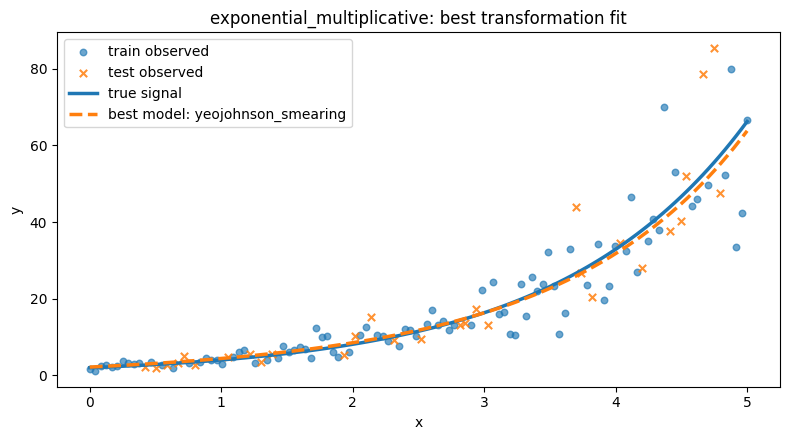

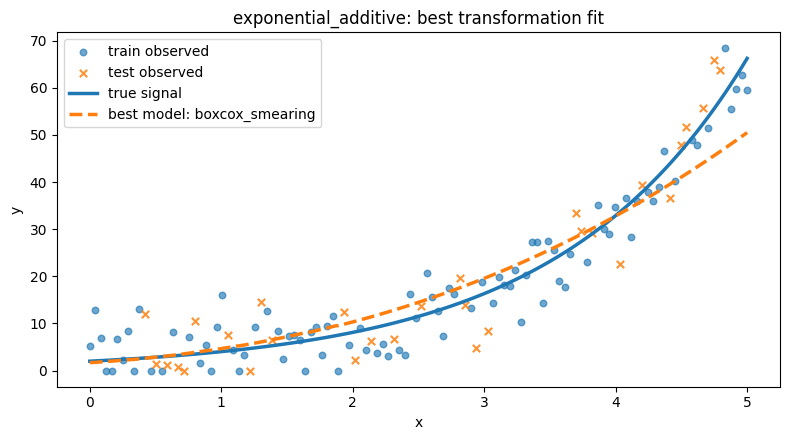

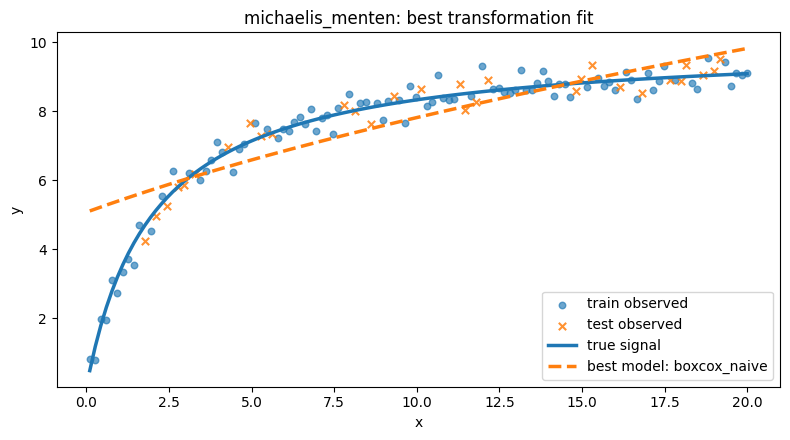

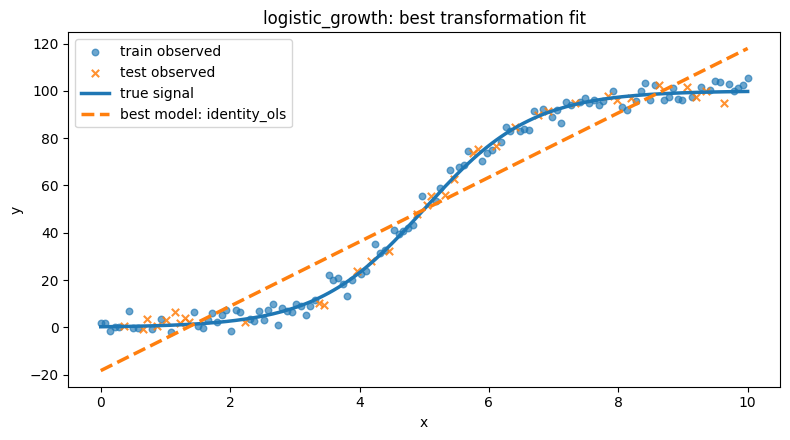

In [9]:
def refit_named_model(model_name: str, train_bundle):
    """Create and fit a fresh model using the stored model name."""
    model = make_model_specs()[model_name]
    X_train, y_train, _ = bundle_arrays(train_bundle)
    model.fit(X_train, y_train)
    return model


def plot_best_fit_for_1d_dataset(
    bundle,
    winners: pd.DataFrame,
    test_size: float = 0.25,
    split_seed: int = 2026,
):
    """Plot the best model fit for one one-dimensional dataset."""
    if bundle.X.shape[1] != 1:
        raise ValueError("This plot helper only supports one-dimensional datasets.")

    winner_row = winners[winners["dataset"].eq(bundle.name)].iloc[0]
    model_name = winner_row["model"]

    train_bundle, test_bundle = td.train_test_split_bundle(
        bundle, test_size=test_size, seed=split_seed
    )

    model = refit_named_model(model_name, train_bundle)

    x_col = bundle.X.columns[0]
    x_min = float(bundle.X[x_col].min())
    x_max = float(bundle.X[x_col].max())
    x_grid = np.linspace(x_min, x_max, 300).reshape(-1, 1)
    y_grid = model.predict(x_grid)

    order = np.argsort(bundle.X[x_col].to_numpy())
    x_sorted = bundle.X[x_col].to_numpy()[order]
    y_true_sorted = bundle.y_true.to_numpy()[order]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.scatter(train_bundle.X[x_col], train_bundle.y, s=22, alpha=0.65, label="train observed")
    ax.scatter(test_bundle.X[x_col], test_bundle.y, s=28, alpha=0.85, marker="x", label="test observed")
    ax.plot(x_sorted, y_true_sorted, linewidth=2.5, label="true signal")
    ax.plot(x_grid.ravel(), y_grid, linewidth=2.5, linestyle="--", label=f"best model: {model_name}")
    ax.set_title(f"{bundle.name}: best transformation fit")
    ax.set_xlabel(x_col)
    ax.set_ylabel("y")
    ax.legend()
    plt.tight_layout()
    return fig, ax


one_dimensional_names = [name for name, bundle in suite.items() if bundle.X.shape[1] == 1]

for name in one_dimensional_names:
    plot_best_fit_for_1d_dataset(suite[name], winners=winners)
    plt.show()


## 9. Inspect Box--Cox and Yeo--Johnson lambda profiles

This section visualizes the profile log-likelihood over $\lambda$ for one selected dataset. Change `PROFILE_DATASET_NAME` to inspect another dataset.


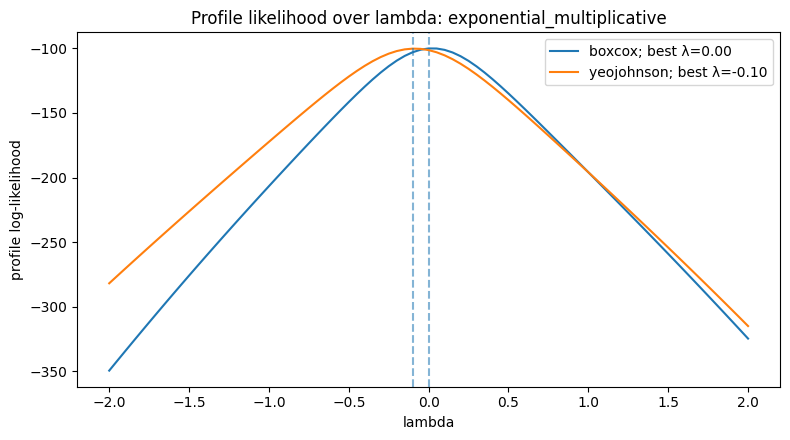

In [10]:
PROFILE_DATASET_NAME = "exponential_multiplicative"

profile_bundle = suite[PROFILE_DATASET_NAME]
train_bundle, _ = td.train_test_split_bundle(profile_bundle, test_size=0.25, seed=2026)
X_profile, y_profile, _ = bundle_arrays(train_bundle)

fig, ax = plt.subplots(figsize=(8, 4.5))

for family in ["boxcox", "yeojohnson"]:
    try:
        best_lambda, table = ta.choose_lambda_by_profile_likelihood(
            X_profile, y_profile, family=family, grid=LAMBDA_GRID
        )
        ax.plot(table["lambda"], table["profile_loglik"], label=f"{family}; best λ={best_lambda:.2f}")
        ax.axvline(best_lambda, linestyle="--", alpha=0.55)
    except Exception as exc:
        warnings.warn(f"Could not compute {family} profile for {PROFILE_DATASET_NAME}: {exc}")

ax.set_title(f"Profile likelihood over lambda: {PROFILE_DATASET_NAME}")
ax.set_xlabel("lambda")
ax.set_ylabel("profile log-likelihood")
ax.legend()
plt.tight_layout()
plt.show()


## 10. Repeated-split robustness experiment

A single train/test split can be noisy. This section repeats the experiment across several random splits and summarizes the mean and standard deviation of RMSE.


In [11]:
def repeated_split_experiment(
    suite: dict,
    split_seeds: list[int] | range = range(100, 110),
    test_size: float = 0.25,
) -> pd.DataFrame:
    """Run the full transformation comparison over repeated random splits."""
    all_rows = []
    for seed in split_seeds:
        split_results = evaluate_suite(suite, test_size=test_size, split_seed=int(seed))
        all_rows.append(split_results)
    return pd.concat(all_rows, ignore_index=True)


repeated_results = repeated_split_experiment(
    suite=suite,
    split_seeds=range(100, 110),
    test_size=0.25,
)

robustness = (
    repeated_results[repeated_results["error"].eq("")]
    .groupby(["dataset", "model", "transform", "use_smearing"], as_index=False)
    .agg(
        rmse_obs_mean=("rmse_obs", "mean"),
        rmse_obs_sd=("rmse_obs", "std"),
        mae_obs_mean=("mae_obs", "mean"),
        r2_obs_mean=("r2_obs", "mean"),
        rmse_signal_mean=("rmse_signal", "mean"),
        r2_signal_mean=("r2_signal", "mean"),
        mean_selected_param_or_lambda=("selected_param_or_lambda", "mean"),
    )
    .sort_values(["dataset", "rmse_obs_mean", "model"])
    .reset_index(drop=True)
)

robust_winners = robustness.groupby("dataset", as_index=False).first()

robustness.head(30)


,dataset,model,transform,use_smearing,rmse_obs_mean,rmse_obs_sd,mae_obs_mean,r2_obs_mean,rmse_signal_mean,r2_signal_mean,mean_selected_param_or_lambda
0,exponential_additive,boxcox_smearing,boxcox,True,6.7579,0.9993,5.3505,0.8443,4.0137,0.9422,0.415
1,exponential_additive,boxcox_naive,boxcox,False,6.8614,1.1135,5.3238,0.8411,4.2627,0.9356,0.415
2,exponential_additive,sqrt_power_smearing,power,True,7.2296,1.0337,5.6838,0.8232,4.7462,0.9200,0.500
3,exponential_additive,sqrt_power_naive,power,False,7.2631,1.1249,5.5825,0.8224,4.7917,0.9189,0.500
4,exponential_additive,yeojohnson_smearing,yeojohnson,True,7.3007,1.1392,5.7322,0.8199,4.8220,0.9174,0.420
5,exponential_additive,yeojohnson_naive,yeojohnson,False,7.3392,1.2295,5.6527,0.8190,4.9297,0.9141,0.420
6,exponential_additive,identity_ols,identity,False,9.4470,1.0952,7.5005,0.6970,7.2040,0.8144,NaN
7,exponential_additive,reciprocal_smearing,reciprocal,True,25.3195,3.2362,18.4713,-1.1548,25.0995,-1.2409,NaN
8,exponential_additive,reciprocal_naive,reciprocal,False,25.3196,3.2363,18.4713,-1.1548,25.0995,-1.2409,NaN
9,exponential_additive,log_naive,log,False,28.2065,14.0286,15.3206,-1.9483,27.8919,-2.0309,NaN


In [12]:
robust_winners[
    [
        "dataset",
        "model",
        "transform",
        "use_smearing",
        "rmse_obs_mean",
        "rmse_obs_sd",
        "r2_obs_mean",
        "rmse_signal_mean",
        "mean_selected_param_or_lambda",
    ]
]


,dataset,model,transform,use_smearing,rmse_obs_mean,rmse_obs_sd,r2_obs_mean,rmse_signal_mean,mean_selected_param_or_lambda
0,exponential_additive,boxcox_smearing,boxcox,True,6.7579,0.9993,0.8443,4.0137,0.415
1,exponential_multiplicative,log_naive,log,False,7.2157,1.8514,0.8229,1.0390,0.010
2,logistic_growth,identity_ols,identity,False,10.9744,0.8586,0.9254,11.0287,0.630
3,michaelis_menten,boxcox_smearing,boxcox,True,0.9688,0.2484,0.6975,0.8962,2.000
4,multivariable_nonlinear,sqrt_power_smearing,power,True,5.0587,0.1627,0.9670,2.1030,0.500


## 11. Save outputs

The notebook saves result tables into `zzu_main_outputs_py_imports/`.

In Colab, you can download the files from the left file browser, or zip the folder at the end.


In [13]:
OUTPUT_DIR = PROJECT_DIR / "zzu_main_outputs_py_imports"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "single_split_results": OUTPUT_DIR / "single_split_results.csv",
    "single_split_winners": OUTPUT_DIR / "single_split_winners.csv",
    "repeated_split_results": OUTPUT_DIR / "repeated_split_results.csv",
    "repeated_split_robustness": OUTPUT_DIR / "repeated_split_robustness.csv",
    "repeated_split_winners": OUTPUT_DIR / "repeated_split_winners.csv",
}

results.to_csv(paths["single_split_results"], index=False)
winners.to_csv(paths["single_split_winners"], index=False)
repeated_results.to_csv(paths["repeated_split_results"], index=False)
robustness.to_csv(paths["repeated_split_robustness"], index=False)
robust_winners.to_csv(paths["repeated_split_winners"], index=False)

paths


{'single_split_results': PosixPath('/Users/ardauzunoglu/zzu-transformations/zzu_main_outputs_py_imports/single_split_results.csv'),
 'single_split_winners': PosixPath('/Users/ardauzunoglu/zzu-transformations/zzu_main_outputs_py_imports/single_split_winners.csv'),
 'repeated_split_results': PosixPath('/Users/ardauzunoglu/zzu-transformations/zzu_main_outputs_py_imports/repeated_split_results.csv'),
 'repeated_split_robustness': PosixPath('/Users/ardauzunoglu/zzu-transformations/zzu_main_outputs_py_imports/repeated_split_robustness.csv'),
 'repeated_split_winners': PosixPath('/Users/ardauzunoglu/zzu-transformations/zzu_main_outputs_py_imports/repeated_split_winners.csv')}